# 02. Modeling : 오류 분석 (H5)
DAY2 Step 6. `src/evaluate.py` 함수만 호출한다 (재학습 없음, Step 3 결과 파일을 읽음).
- 입력 : `results/model_comparison.csv`, `results/predictions.csv`, `processed/features.csv`
- 그래프 : `results/figures/D2_*.png`
- 선행 실행 : `python -m src.features` → `python -m src.split` → `python -m src.train`

In [1]:
import os, sys
import pandas as pd

# 노트북 위치가 루트든 notebooks/ 든 프로젝트 루트를 sys.path에 추가 (src 패키지 import용)
ROOT = os.path.abspath('..') if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
sys.path.insert(0, ROOT)
from src import evaluate as ev

FINAL_MODEL = None   # None = src.train.FINAL_MODEL (C_elasticnet). 다른 모델을 보려면 이름으로 지정 (예 : 'A_linear')

In [2]:
model, comp, pred, t = ev.run_all_tables(FINAL_MODEL)
train_range = ev.train_logvar_range()
print('최종 모델 :', model)
print(f'Batch 1 학습 log_var 범위 : {train_range[0]:.3f} ~ {train_range[1]:.3f}')

최종 모델 : C_elasticnet
Batch 1 학습 log_var 범위 : -4.179 ~ -3.350


## 1. 모델 비교 (MAPE %)

In [3]:
t['model'].round(2)

,model,feature_set,train_mape,valid_mape,b2_mape,b3_mape,candidate
0,A_linear,A_variance,8.87,8.47,28.56,12.81,False
1,B_ridge,B_deltaQ,8.99,11.41,30.32,12.20,False
2,B_elasticnet,B_deltaQ,9.20,10.31,30.11,12.34,False
3,C_elasticnet,C_full,5.91,5.61,25.63,13.21,True
4,B_rf,B_deltaQ,9.63,10.21,29.84,18.18,False
5,B_gbr,B_deltaQ,8.96,9.69,31.67,18.68,False


## 2. Batch 2 구조별 MAPE
`log_resid` = log10(예측) − log10(실제), (+) = 과대예측. `n_over` = 과대예측 셀 수

In [4]:
t['structure'].round(3)

,model,structure,n_cells,mape,median_log_resid,n_over
0,A_linear,old,30,31.869,0.121,30
1,A_linear,new,9,17.527,0.026,8
2,B_ridge,old,30,34.844,0.131,30
3,B_ridge,new,9,15.254,0.011,6
4,B_elasticnet,old,30,34.406,0.128,30
5,B_elasticnet,new,9,15.792,0.019,6
6,C_elasticnet,old,30,25.637,0.109,28
7,C_elasticnet,new,9,25.595,0.073,8
8,B_rf,old,30,34.964,0.124,30
9,B_rf,new,9,12.778,0.011,5


## 3. Batch 3 노이즈 셀 포함 / 제외 MAPE
노이즈 셀 : b3c2, b3c37, b3c42, b3c43

In [5]:
t['noise'].round(2)

,model,mape_all,n_all,mape_excl_noisy,n_excl_noisy,mape_noisy_only,n_noisy
0,A_linear,12.81,44,11.75,40,23.48,4
1,B_ridge,12.20,44,12.11,40,13.10,4
2,B_elasticnet,12.34,44,11.59,40,19.79,4
3,C_elasticnet,13.21,44,9.71,40,48.28,4
4,B_rf,18.18,44,16.87,40,31.27,4
5,B_gbr,18.68,44,17.23,40,33.12,4


In [6]:
t['noisy_cells'].round(3)

,cell_id,y_true,y_pred,ape,log_var
0,b3c2,1267.0,821.204,35.185,-4.779
1,b3c37,1390.0,580.919,58.207,-5.099
2,b3c42,1642.0,471.579,71.280,-4.346
3,b3c43,1046.0,748.451,28.446,-4.317


## 4. 오차 상위 10셀 (Batch 2·3)

In [7]:
t['top10'].round(3)

,cell_id,batch,structure,policy,y_true,y_pred,ape,log_var,over_under
0,b2c44,b2,new,5.2C(58%)-4C-newstructure,841.0,1451.680,72.614,-4.365,over
1,b3c42,b3,new,4.8C(80%)-4.8C-newstructure,1642.0,471.579,71.280,-4.346,under
2,b3c37,b3,new,4.8C(80%)-4.8C-newstructure,1390.0,580.919,58.207,-5.099,under
3,b2c9,b2,new,5.6C(26%)-4.5C-newstructure,791.0,1217.337,53.898,-4.344,over
4,b2c31,b2,old,5.6C(26%)-4.5C,425.0,615.997,44.941,-3.352,over
5,b2c2,b2,old,5.2C(50%)-4.25C,424.0,592.600,39.764,-3.460,over
6,b2c13,b2,old,4.65C(69%)-6C,460.0,629.031,36.746,-3.344,over
7,b3c38,b3,new,5C(67%)-4C-newstructure,1935.0,1234.570,36.198,-4.342,under
8,b2c4,b2,old,4.65C(69%)-6C,444.0,603.738,35.977,-3.233,over
9,b3c2,b3,new,5.6C(19%)-4.6C-newstructure,1267.0,821.204,35.185,-4.779,under


In [8]:
# 비교용 : A_linear (베이스라인)
ev.top_errors(pred, 'A_linear').round(3)

,cell_id,batch,structure,policy,y_true,y_pred,ape,log_var,over_under
0,b2c6,b2,old,3.6C(9%)-5C,393.0,648.194,64.935,-3.530,over
1,b2c18,b2,old,5.2C(50%)-4.25C,449.0,731.807,62.986,-3.707,over
2,b2c15,b2,old,3.6C(9%)-5C,396.0,642.106,62.148,-3.516,over
3,b2c2,b2,old,5.2C(50%)-4.25C,424.0,617.959,45.745,-3.460,over
4,b2c9,b2,new,5.6C(26%)-4.5C-newstructure,791.0,1131.826,43.088,-4.344,over
5,b3c38,b3,new,5C(67%)-4C-newstructure,1935.0,1129.990,41.603,-4.342,under
6,b2c29,b2,old,5.2C(58%)-4C,452.0,638.598,41.283,-3.508,over
7,b2c19,b2,old,6C(60%)-3C,392.0,550.726,40.491,-3.292,over
8,b2c11,b2,old,5.2C(50%)-4.25C,449.0,628.687,40.019,-3.485,over
9,b2c21,b2,old,6C(60%)-3C,408.0,563.971,38.228,-3.327,over


## 5. 그래프

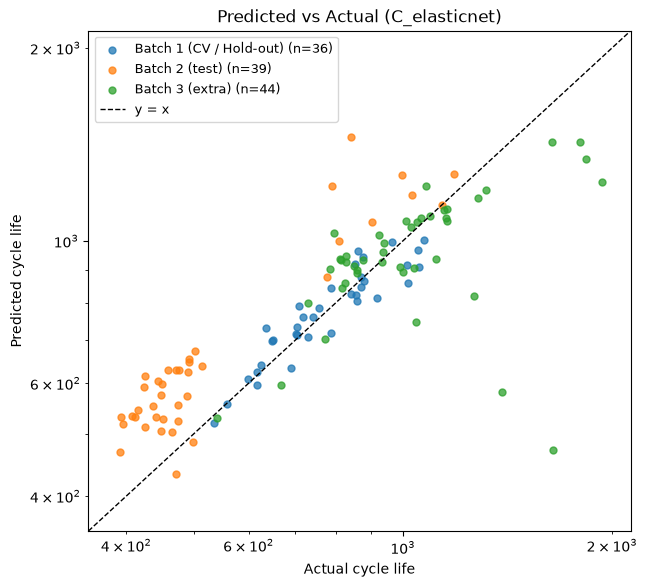

In [9]:
ev.plot_pred_vs_true(pred, model);

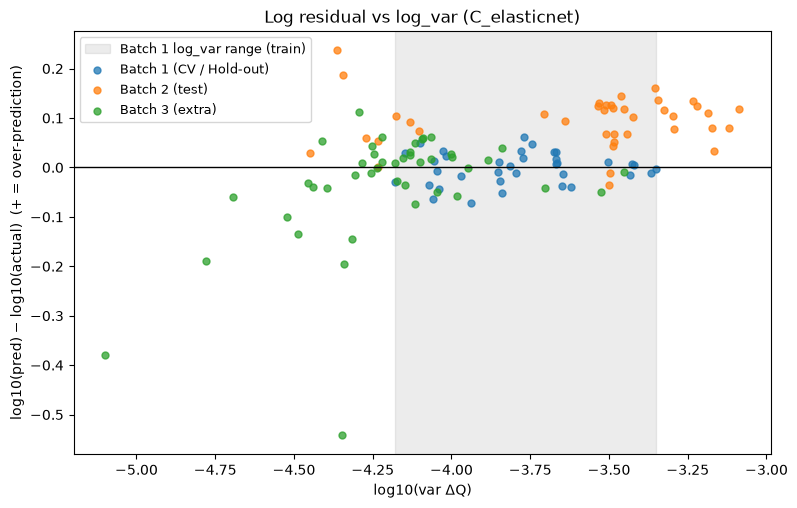

In [10]:
ev.plot_resid_vs_logvar(pred, model, train_range);

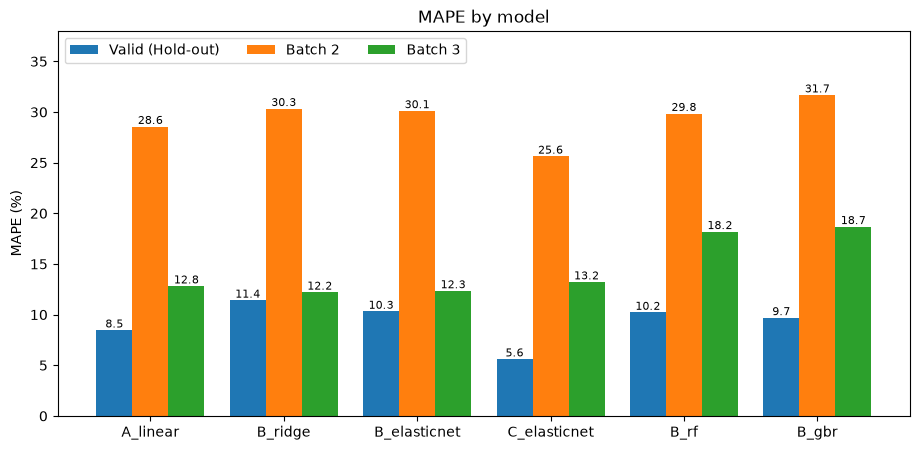

In [11]:
ev.plot_mape_bars(comp);